# MEN 01 — Motion energy: quality control

What the motion-energy (ME) data look like, which cameras pass the video QC, what the QC changes,
and the checks the later analyses (`men_00`, `fip_10`–`fip_16`) rest on.

ME comes from the aligned ME table (`fip_motion_energy_aligned`), built for the 97 FIP sessions
used in the `fip_*` notebooks, two cameras each. Two screens decide which cameras are used:

- **Timing** (video-analysis library `video_timing_qc`, applied when the table was built): each
  frame gets its Harp time from the camera trigger log. Dropped frames are re-indexed, isolated Harp
  glitches are fixed, and cameras whose Harp clock steps or whose trigger log does not match the
  frames are refused.
- **Image quality** (library `video_quality_qc`, applied by `fu.load_me_index` from
  `inputs/video_screen_fip.csv`): about 100 keyframes per camera; cameras that are overexposed
  (side cameras: median clipped pixels > 3.75%), too dark or bright, blurred, or not showing the
  mouse are excluded.

1. An example session
2. Timing QC
3. Image-quality QC
4. What the QC removes
5. Checks for the later analyses: ME scale, ME onset rate, agreement between cameras

## Setup

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

import fip_utils as fu
import men_utils as mu
import signal_utils as su
import stats_utils as st
from plotstyle import apply_style, style_ax, save_fig, PALETTE, OKABE_ITO

apply_style()
warnings.filterwarnings("ignore", message="Mean of empty slice")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

In [2]:
IS_CO = os.path.isdir("/root/capsule")

# Same sources and cache as men_00 (the cache key must match men_00's call to be reused)
ASSET_CANDIDATES = {
    "3ch": ["/root/capsule/data/DANE_3channels_curated",
            "../../data/results-a278f830-9bf2-48e8-9928-a2ff78e4818f"],
    "4ch": ["/root/capsule/data/DANE_4channels_curated",
            "../../data/results-ddcccb0f-f18f-44a6-a2b1-caba680d28a1"],
}
ME_DATA_ROOT = "/root/capsule/data" if IS_CO else os.environ.get("ME_DATA_ROOT", "../../data")
CACHE_PATH = ("/root/capsule/scratch/men_00/sessions.pkl" if IS_CO
              else os.environ.get("MEN_CACHE", "../../data/men_00_cache/sessions.pkl"))
# Per-camera session cards written by the library's screen (local only; panel skipped without them)
SCREEN_DIR = os.environ.get("VIDEO_SCREEN_DIR", "../../aind-dynamic-foraging-behavior-video-analysis/"
                                                "video_quality_qc_data/screen_fip")
FIG_DIR = "/root/capsule/scratch/figures/men" if IS_CO else "../data/figures/men"
SAVE_FIG = True

CAMERAS = ("BottomCamera", "SideCameraRight")
CAM_LABEL = {"BottomCamera": "bottom", "SideCameraRight": "side"}
SOURCE_NAME = {"BottomCamera": "bottom_camera", "SideCameraRight": "side_camera_right"}
FS = 100.0                     # men_00's grid
EXAMPLE_SESSION = None         # None = both cameras usable, Harp as written, median ME onset rate
EXAMPLE_WIN_S = 60.0
LICK_LAGS = np.arange(-1.0, 1.0 + 1e-9, 1 / FS)
CLOCK_TOL_S = 0.15             # men_00's clock-check tolerance
CLIP_MAX_PCT = 3.75            # side cameras: median clipped pixels (library CHECKS)
LUMA_BAND = (50, 150)          # mean luma (library CHECKS)

TIMING_ORDER = ["as written", "glitches fixed", "re-indexed", "refused: Harp clock step",
                "refused: trigger log"]
TIMING_COLOR = {"as written": "0.55", "glitches fixed": OKABE_ITO["sky_blue"],
                "re-indexed": OKABE_ITO["blue"], "refused: Harp clock step": OKABE_ITO["vermillion"],
                "refused: trigger log": OKABE_ITO["orange"]}
USE_COLOR = {True: "0.35", False: OKABE_ITO["vermillion"]}
CAM_COLOR = {"BottomCamera": "0.25", "SideCameraRight": OKABE_ITO["sky_blue"]}

## 0. Data

The ME table index with and without the image-quality screen, the screen itself, and `men_00`'s
session cache (trials, licks and ME on a 100 Hz grid, task ± 30 s). The cache holds no ME for a
camera either screen excludes.

In [3]:
idx_build = fu.load_me_index(ME_DATA_ROOT, screen=False)     # timing QC only
idx = fu.load_me_index(ME_DATA_ROOT)                          # + image-quality screen
screen = pd.read_csv(fu.VIDEO_SCREEN_CSV)
screen = screen[screen["session"].isin(idx["session"])].copy()
screen["subject"] = screen["subject"].astype(str)
screen["quality_ok"] = screen["quality"].eq("use")      # the image-quality verdict alone


def timing_category(r):
    if r["status"] == "ok":
        return {"use harp as written": "as written", "fix glitches": "glitches fixed",
                "re-index": "re-indexed"}[r["action"]]
    return ("refused: Harp clock step" if "harp_evenly_spaced" in str(r["failed_checks"])
            else "refused: trigger log")


idx_build["timing"] = idx_build.apply(timing_category, axis=1)
idx_build["subject"] = idx_build["subject"].astype(str)
usable = idx.set_index(["session", "camera"])["status"].eq("ok")      # passed both screens
idx_build["use"] = [bool(usable[(a, b)]) for a, b in zip(idx_build["session"], idx_build["camera"])]

asset_roots = {n: r for n, c in ASSET_CANDIDATES.items() if (r := fu.find_asset_root(c))}
inv = mu.inventory_sessions(asset_roots, idx)
inv["has_trials"] = inv["path"].notna()
sessions = mu.load_sessions(inv[inv.has_trials], fs=FS, cache_path=CACHE_PATH,
                            data_root=ME_DATA_ROOT, cameras=CAMERAS)
for s in sessions:
    s["me_n"] = {cam: (mu.normalise(x, "z") if x is not None else None) for cam, x in s["me"].items()}
by_session = {s["session"]: s for s in sessions}
SUBJECTS = sorted(idx_build["subject"].unique())
print(f"{idx_build.session.nunique()} sessions, {len(idx_build)} cameras, {len(SUBJECTS)} mice; "
      f"{len(sessions)} sessions in the men_00 cache")

loaded 97 sessions from cache ../../data/men_00_cache/sessions.pkl


97 sessions, 194 cameras, 9 mice; 97 sessions in the men_00 cache


## 1. An example session

Bottom- and side-camera ME (z-scored over the task) with the task events: go cues, rewarded and
unrewarded outcomes, ignored cues, and left and right licks. Top: the whole session, as a 10-s
running mean; the shaded stretch is shown below at full resolution (100 Hz).

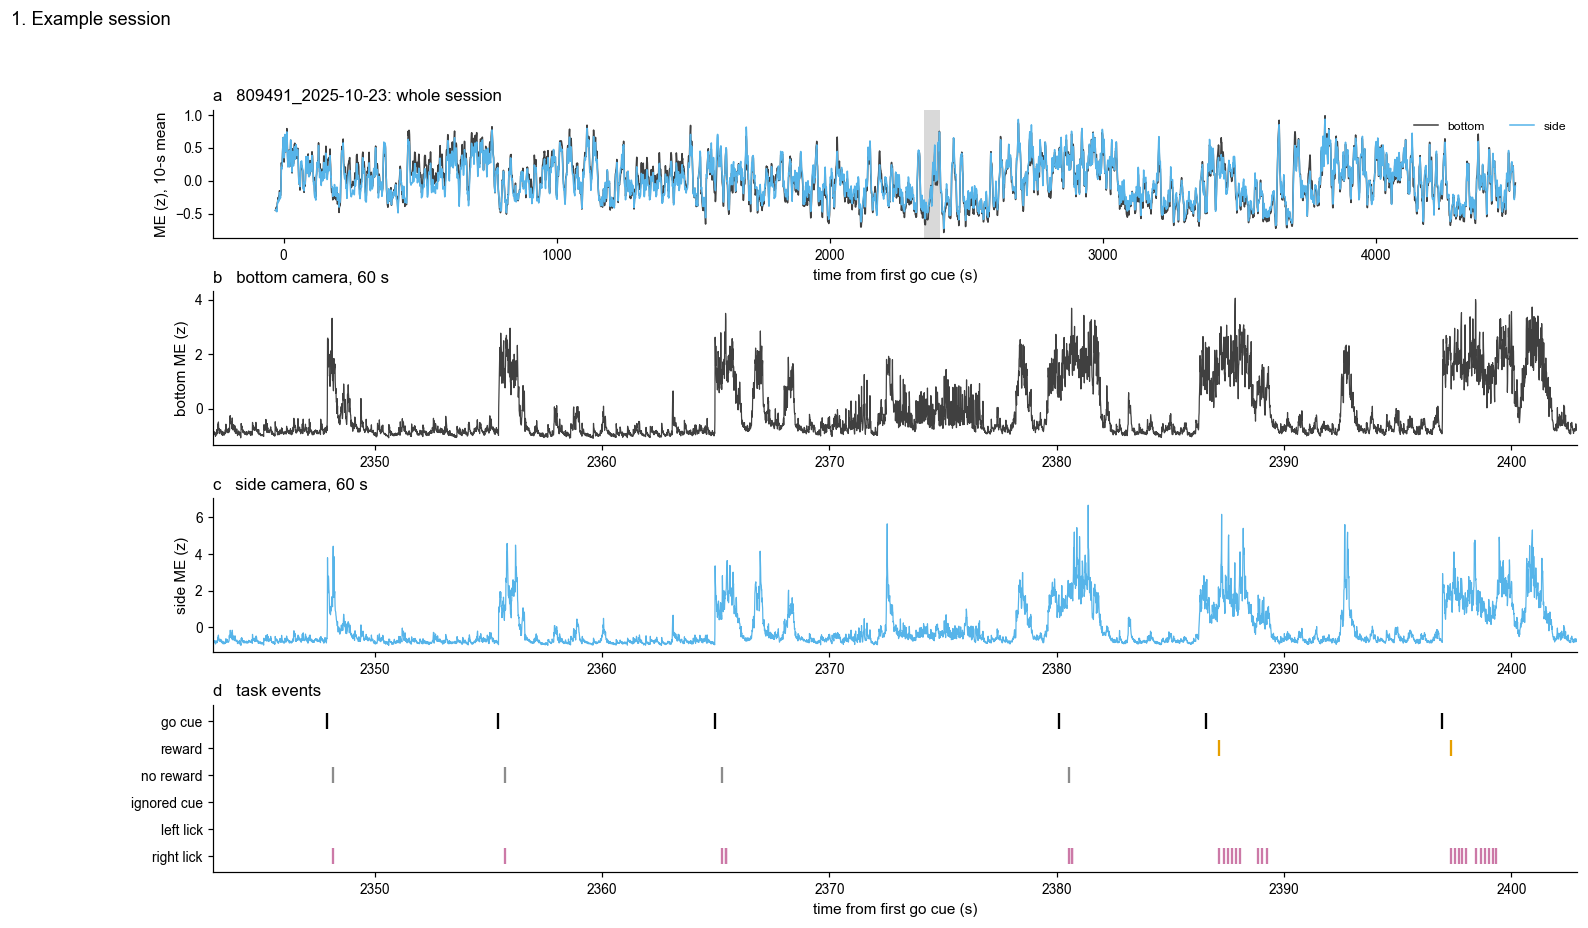

In [4]:
def onsets_per_min(s, cam="BottomCamera"):
    x = s["me_n"][cam]
    if x is None:
        return np.nan
    t = s["t0"] + np.arange(len(x)) / FS
    return len(su.threshold_onsets(t, x, already_z=True, **fu.ME_ONSET_KW)) / (len(x) / FS / 60)


clean = idx_build.groupby("session").apply(
    lambda g: (g["timing"] == "as written").all() and g["use"].all(), include_groups=False)
if EXAMPLE_SESSION is None:
    cand = [by_session[ses] for ses in idx.loc[idx["session"].isin(clean[clean].index), "ses_idx"].unique()
            if ses in by_session]
    rates = pd.Series({s["session"]: onsets_per_min(s) for s in cand})
    EXAMPLE_SESSION = (rates - rates.median()).abs().idxmin()
ex = by_session[EXAMPLE_SESSION]
tr = ex["trials"]
responded = tr["animal_response"] != 2
rewarded = responded & (tr["earned_reward"].fillna(0) > 0)
outc = tr["reward_outcome_time_in_session"]
le = ex["lick_events"]
rows = [("go cue", tr["goCue_start_time_in_session"], "k"),
        ("reward", outc[rewarded], OKABE_ITO["orange"]),
        ("no reward", outc[responded & ~rewarded], "0.55"),
        ("ignored cue", tr.loc[~responded, "goCue_start_time_in_session"], OKABE_ITO["sky_blue"]),
        ("left lick", le.loc[le.event == "left_lick_time", "timestamps"], OKABE_ITO["bluish_green"]),
        ("right lick", le.loc[le.event == "right_lick_time", "timestamps"], OKABE_ITO["reddish_purple"])]

t = ex["t0"] + np.arange(len(ex["me_n"]["BottomCamera"])) / FS
cues = tr["goCue_start_time_in_session"].dropna().to_numpy()
rew_t, unrew_t = outc[rewarded].dropna().to_numpy(), outc[responded & ~rewarded].dropna().to_numpy()
# first window from mid-session on with at least two rewarded and two unrewarded outcomes
for c in cues[cues >= np.median(cues)]:
    win = (c - 5.0, c - 5.0 + EXAMPLE_WIN_S)
    if (((rew_t >= win[0]) & (rew_t < win[1])).sum() >= 2
            and ((unrew_t >= win[0]) & (unrew_t < win[1])).sum() >= 2):
        break

fig = plt.figure(figsize=(16, 9))
gs = GridSpec(4, 1, figure=fig, height_ratios=[1.0, 1.2, 1.2, 1.3], hspace=0.35)
ax0 = fig.add_subplot(gs[0])
for cam in CAMERAS:
    x = ex["me_n"][cam]
    if x is not None:
        tc, y = su.rolling_mean(x, FS, 10.0, 1.0)
        ax0.plot(ex["t0"] + tc, y, color=CAM_COLOR[cam], lw=1, label=CAM_LABEL[cam])
ax0.axvspan(*win, color="0.85", lw=0, zorder=0)
ax0.set(ylabel="ME (z), 10-s mean", xlabel="time from first go cue (s)")
ax0.set_title(f"a   {ex['session']}: whole session", loc="left")
ax0.legend(fontsize=8, ncol=2, loc="upper right")
style_ax(ax0)
m = (t >= win[0]) & (t < win[1])
ax = None
for k, cam in enumerate(CAMERAS):
    ax = fig.add_subplot(gs[1 + k], sharex=ax)
    ax.plot(t[m], ex["me_n"][cam][m], color=CAM_COLOR[cam], lw=0.8)
    ax.set_ylabel(f"{CAM_LABEL[cam]} ME (z)")
    ax.set_title(f"{'bc'[k]}   {CAM_LABEL[cam]} camera, {EXAMPLE_WIN_S:.0f} s", loc="left")
    style_ax(ax)
ax = fig.add_subplot(gs[3], sharex=ax)
for y, (name, times, color) in enumerate(rows):
    tt = np.asarray(times.dropna(), float)
    tt = tt[(tt >= win[0]) & (tt < win[1])]
    ax.plot(tt, np.full(len(tt), -y), "|", color=color, ms=10, mew=1.5)
ax.set_yticks(-np.arange(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.set_ylim(-len(rows) + 0.4, 0.6)
ax.set_xlim(*win)
ax.set_xlabel("time from first go cue (s)")
ax.set_title("d   task events", loc="left")
style_ax(ax)
fig.suptitle("1. Example session", x=0.01, ha="left")
save_fig(fig, "men01_1_example", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 2. Timing QC

**a** What the timing QC did to each camera. **b** Frames lost (the camera skipped an exposure and
wrote no frame), as a fraction of exposures, for cameras that were re-indexed. **c** What ignoring
it would cost: at the end of the session, the time a frame would get from its row number
(`row / frame rate`) minus its corrected Harp time. **d** The clock check after correction:
lick-triggered ME peak lag per camera (`mu.lick_clock_check`), by timing category. The lickometer
registers contact, so a peak a few tens of ms before the lick is expected; the band is ±0.15 s.

In [5]:
# c: clock error a row-count clock would accumulate, per usable camera
err_rows = []
for r in idx_build[idx_build["status"] == "ok"].itertuples():
    f = pd.read_parquet(os.path.join(ME_DATA_ROOT, fu.ME_TABLE_NAME, r.session, f"{r.camera}.parquet"),
                        columns=["harp_time", "frame_number"])
    harp = f["harp_time"].to_numpy()
    err_rows.append(dict(session=r.session, camera=r.camera, subject=r.subject, timing=r.timing,
                         minutes=(harp[-1] - harp[0]) / 60,
                         row_clock_error_s=(len(harp) - 1) * r.frame_interval_s - (harp[-1] - harp[0])))
err = pd.DataFrame(err_rows)
idx_build["lost_frac"] = idx_build["frames_lost"].fillna(0) / (idx_build["n_frames"] + idx_build["frames_lost"].fillna(0))

clock, _ = mu.lick_clock_check(sessions, CAMERAS, FS, LICK_LAGS)
clock = clock.merge(idx[["ses_idx", "camera", "session"]].rename(columns={"session": "raw"}),
                    left_on=["session", "camera"], right_on=["ses_idx", "camera"])
clock = clock.merge(idx_build[["session", "camera", "timing"]], left_on=["raw", "camera"],
                    right_on=["session", "camera"], suffixes=("", "_b"))

print(pd.crosstab(idx_build["timing"], idx_build["camera"]).reindex(TIMING_ORDER).fillna(0).astype(int))
print()
print("row-clock error at session end (s), usable cameras:")
print(err.groupby("timing")["row_clock_error_s"].describe()[["count", "50%", "max"]].round(3))
print()
print("clock check, peak lag (s):")
print(clock.groupby(["camera", "timing"])["peak_lag_s"].describe()[["count", "50%", "min", "max"]].round(3))

camera                    BottomCamera  SideCameraRight
timing                                                 
as written                          63               63
glitches fixed                      10               10
re-indexed                          15               17
refused: Harp clock step             6                6
refused: trigger log                 3                1

row-clock error at session end (s), usable cameras:
                count      50%      max
timing                                 
as written      126.0   -0.000    0.000
glitches fixed   20.0   -0.000    0.000
re-indexed       32.0 -354.102 -280.292

clock check, peak lag (s):
                                count   50%   min   max
camera          timing                                 
BottomCamera    as written       63.0 -0.02 -0.07  0.07
                glitches fixed   10.0 -0.04 -0.07  0.00
                re-indexed       15.0 -0.02 -0.04  0.00
SideCameraRight as written       39.0 -0.05 -0.

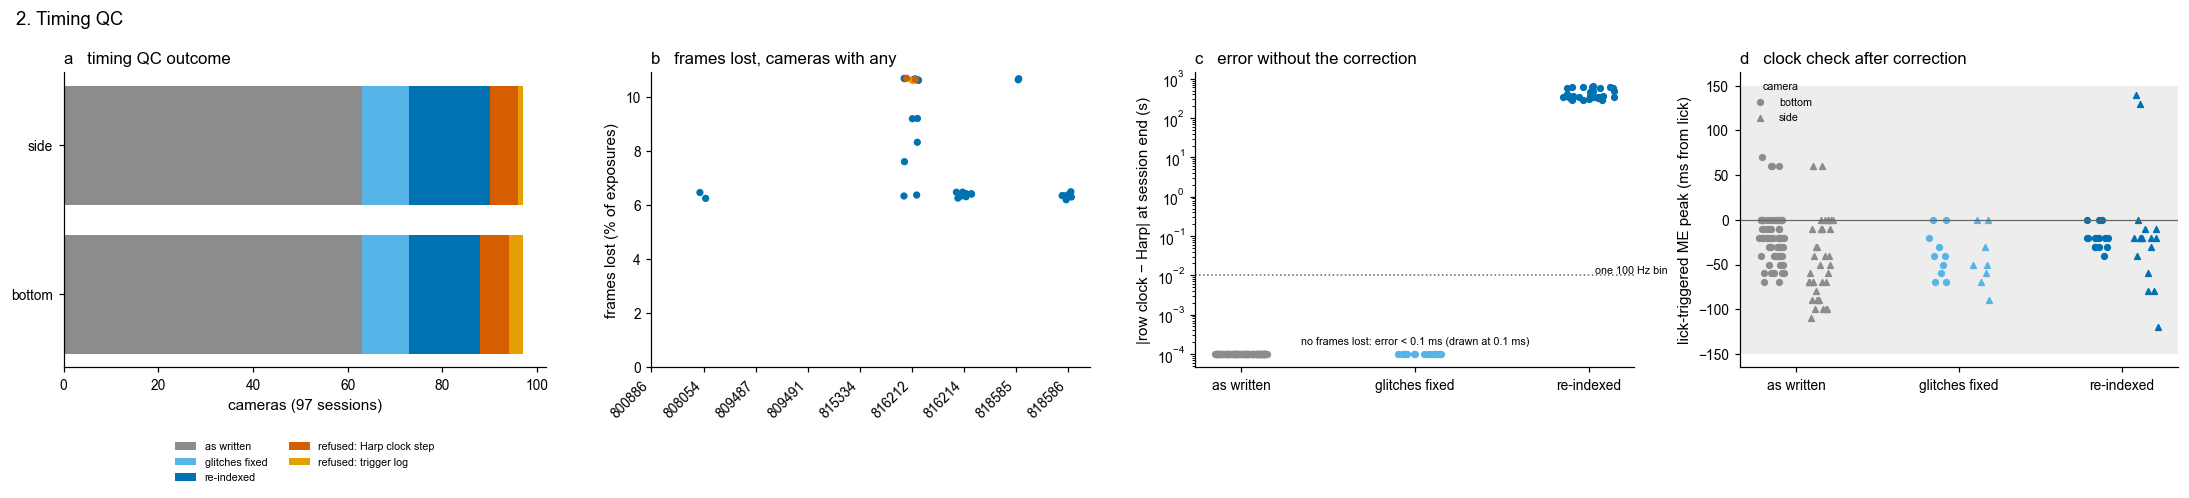

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), gridspec_kw=dict(width_ratios=[1.1, 1, 1, 1]))
ax = axes[0]
ct = pd.crosstab(idx_build["camera"], idx_build["timing"]).reindex(columns=TIMING_ORDER).fillna(0)
left = np.zeros(len(ct))
for cat in TIMING_ORDER:
    ax.barh([CAM_LABEL[c] for c in ct.index], ct[cat], left=left, color=TIMING_COLOR[cat], label=cat)
    left += ct[cat].to_numpy()
ax.set(xlabel="cameras (97 sessions)")
ax.set_title("a   timing QC outcome", loc="left")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=False)
style_ax(ax)

rng = np.random.default_rng(0)
ax = axes[1]
d = idx_build[idx_build["frames_lost"].fillna(0) > 0]
for k, subj in enumerate(SUBJECTS):
    g = d[d.subject == subj]
    ax.scatter(k + (rng.random(len(g)) - 0.5) * 0.3, 100 * g["lost_frac"], s=14,
               color=[TIMING_COLOR[c] for c in g["timing"]])
ax.set_ylim(0, None)
ax.set_xticks(range(len(SUBJECTS)))
ax.set_xticklabels(SUBJECTS, rotation=45, ha="right")
ax.set(ylabel="frames lost (% of exposures)")
ax.set_title("b   frames lost, cameras with any", loc="left")
style_ax(ax)

ax = axes[2]
for k, cat in enumerate(TIMING_ORDER[:3]):
    v = err.loc[err.timing == cat, "row_clock_error_s"].abs().clip(lower=1e-4)
    ax.scatter(k + (rng.random(len(v)) - 0.5) * 0.3, v, s=14, color=TIMING_COLOR[cat])
ax.axhline(1 / FS, color=PALETTE["neutral"], ls=":", lw=1)
ax.text(2.45, 1 / FS, "one 100 Hz bin", fontsize=7, va="bottom", ha="right")
ax.text(1.0, 1.5e-4, "no frames lost: error < 0.1 ms (drawn at 0.1 ms)", fontsize=7, ha="center", va="bottom")
ax.set_yscale("log")
ax.set_xticks(range(3))
ax.set_xticklabels(TIMING_ORDER[:3])
ax.set(ylabel="|row clock − Harp| at session end (s)")
ax.set_title("c   error without the correction", loc="left")
style_ax(ax)

ax = axes[3]
for j, cam in enumerate(CAMERAS):
    for k, cat in enumerate(TIMING_ORDER[:3]):
        v = clock.loc[(clock.camera == cam) & (clock.timing == cat), "peak_lag_s"]
        ax.scatter(k + (j - 0.5) * 0.3 + (rng.random(len(v)) - 0.5) * 0.15, v * 1000, s=14,
                   color=TIMING_COLOR[cat], marker="o" if j == 0 else "^",
                   label=CAM_LABEL[cam] if k == 0 else None)
ax.axhspan(-CLOCK_TOL_S * 1000, CLOCK_TOL_S * 1000, color="0.93", lw=0, zorder=0)
ax.axhline(0, color=PALETTE["neutral"], lw=0.8)
ax.set_xticks(range(3))
ax.set_xticklabels(TIMING_ORDER[:3])
ax.set(ylabel="lick-triggered ME peak (ms from lick)")
ax.set_title("d   clock check after correction", loc="left")
ax.legend(fontsize=7, title="camera", title_fontsize=7)
style_ax(ax)
fig.suptitle("2. Timing QC", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men01_2_timing", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 3. Image-quality QC

**a** The screen's reference frame (median of ~100 keyframes; red = clipped at the top of the
range, blue = at the bottom) for a typical bottom camera, a side camera that passed, and the
side camera with the most clipping, from the library's session cards. **b** Median fraction of
clipped pixels per camera, by mouse; side cameras above 3.75% are excluded. **c** Mean luma per
camera against the accepted 50–150 band.

In [7]:
def reference_crop(session, camera):
    # The reference-frame panel of a library session card (top-left of the card)
    path = os.path.join(SCREEN_DIR, session, f"session_card_{SOURCE_NAME[camera]}.png")
    if not os.path.exists(path):
        return None
    im = Image.open(path)
    w, h = im.size
    return im.crop((int(0.06 * w), int(0.125 * h), int(0.335 * w), int(0.385 * h)))


side, bottom = screen[screen.camera == "SideCameraRight"], screen[screen.camera == "BottomCamera"]
examples = [
    ("bottom, typical", bottom.iloc[(bottom["pct_clipped_high"] - bottom["pct_clipped_high"].median()).abs().argmin()]),
    ("side, passed", side[side.quality_ok].iloc[(side[side.quality_ok]["pct_clipped_high"]
                                          - side[side.quality_ok]["pct_clipped_high"].median()).abs().argmin()]),
    ("side, excluded", side.loc[side["pct_clipped_high"].idxmax()]),
]
crops = [(lab, r, reference_crop(r["session"], r["camera"])) for lab, r in examples]
print(screen.groupby(["camera", "quality_ok"]).size().unstack(fill_value=0))
print()
print(screen.loc[~screen.use, "reason"].value_counts())

quality_ok       False  True 
camera                       
BottomCamera         0     97
SideCameraRight     28     69

reason
quality: exclude: pct_clipped_high median <= 3.75    26
timing: exclude: harp_evenly_spaced                  12
timing: exclude: trigger_log_count                    4
Name: count, dtype: int64


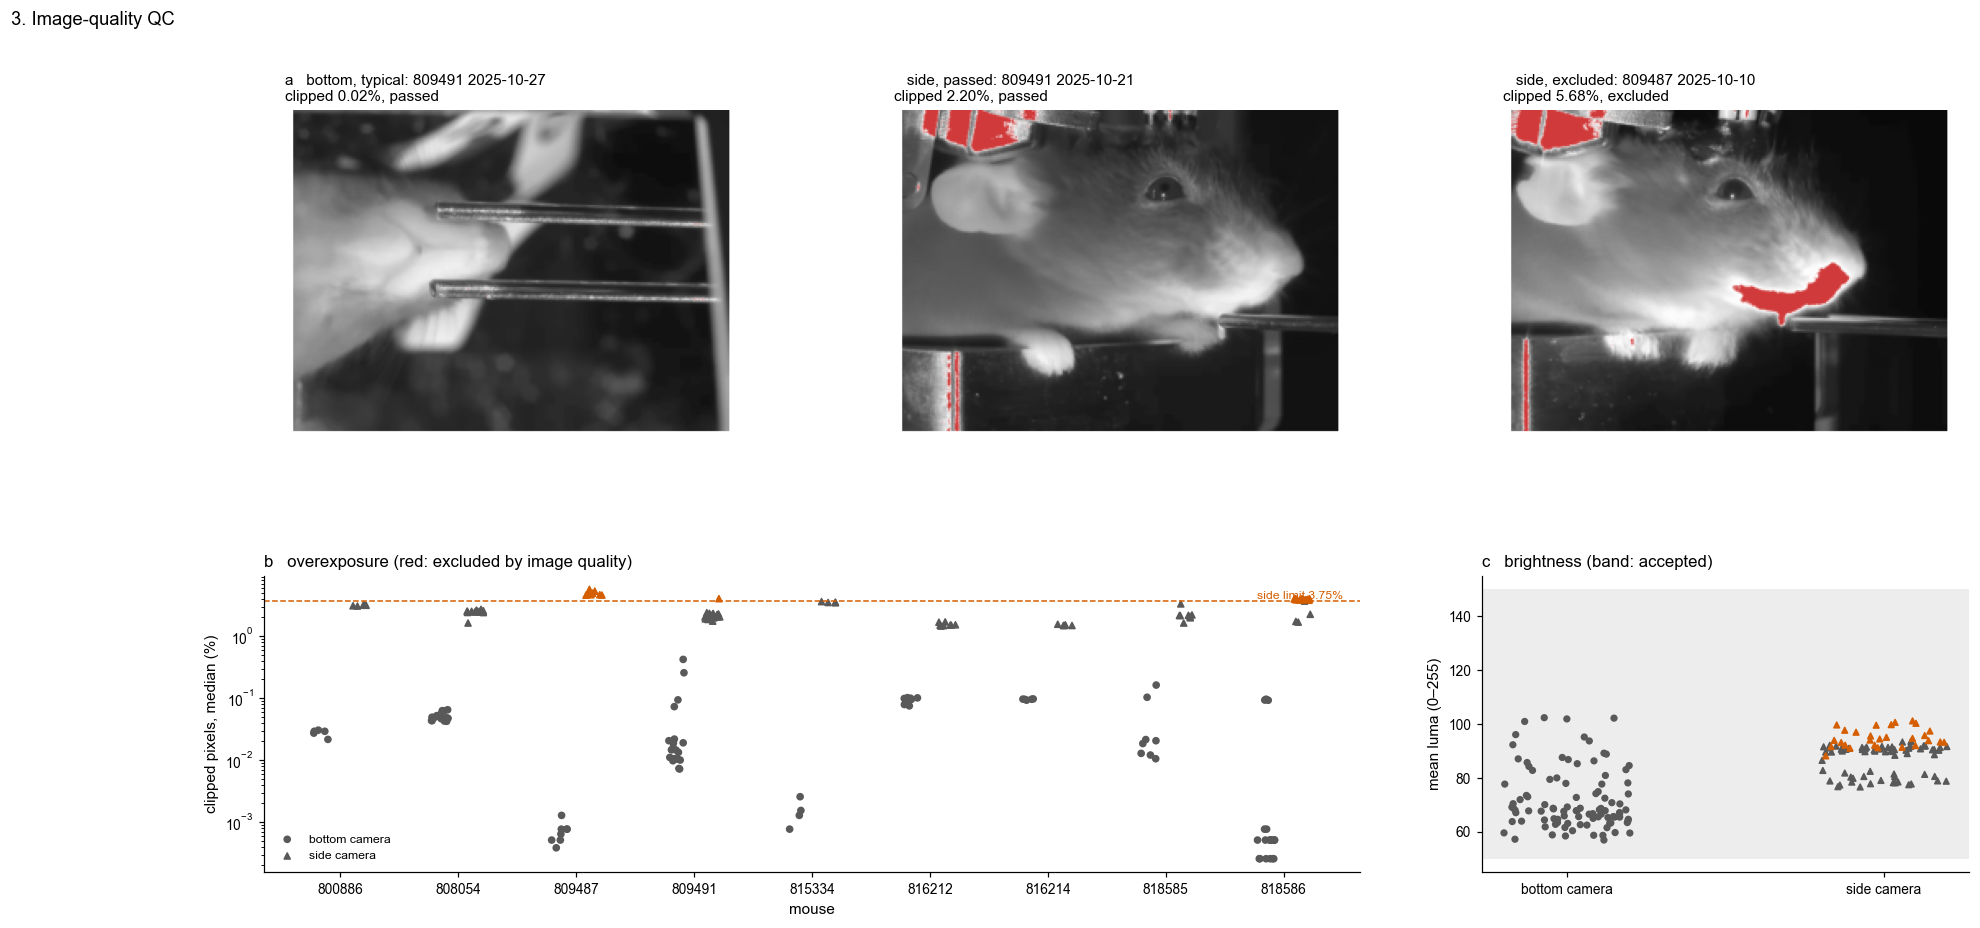

In [8]:
fig = plt.figure(figsize=(20, 9))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.1, 1], hspace=0.45, wspace=0.25)
for k, (lab, r, im) in enumerate(crops):
    ax = fig.add_subplot(gs[0, k])
    if im is not None:
        ax.imshow(im)
    ax.set_axis_off()
    verdict = "passed" if r["quality_ok"] else "excluded"
    ax.set_title(f"{'a' if k == 0 else ''}   {lab}: {r['session'].split('_')[1]} {r['session'].split('_')[2]}\n"
                 f"clipped {r['pct_clipped_high']:.2f}%, {verdict}", loc="left", fontsize=10)

rng = np.random.default_rng(0)
ax = fig.add_subplot(gs[1, :2])
for j, cam in enumerate(CAMERAS):
    for k, subj in enumerate(SUBJECTS):
        g = screen[(screen.camera == cam) & (screen.subject == subj)]
        ax.scatter(k + (j - 0.5) * 0.3 + (rng.random(len(g)) - 0.5) * 0.15, g["pct_clipped_high"], s=16,
                   color=[USE_COLOR[u] for u in g["quality_ok"]], marker="o" if j == 0 else "^",
                   label=f"{CAM_LABEL[cam]} camera" if k == 0 else None)
ax.axhline(CLIP_MAX_PCT, color=OKABE_ITO["vermillion"], ls="--", lw=1)
ax.text(len(SUBJECTS) - 0.5, CLIP_MAX_PCT, f"side limit {CLIP_MAX_PCT}%", fontsize=8, va="bottom", ha="right",
        color=OKABE_ITO["vermillion"])
ax.set_yscale("log")
ax.set_xticks(range(len(SUBJECTS)))
ax.set_xticklabels(SUBJECTS)
ax.set(ylabel="clipped pixels, median (%)", xlabel="mouse")
ax.set_title("b   overexposure (red: excluded by image quality)", loc="left")
ax.legend(fontsize=8)
style_ax(ax)

ax = fig.add_subplot(gs[1, 2])
for j, cam in enumerate(CAMERAS):
    g = screen[screen.camera == cam]
    ax.scatter(j + (rng.random(len(g)) - 0.5) * 0.4, g["mean"], s=14, color=[USE_COLOR[u] for u in g["quality_ok"]],
               marker="o" if j == 0 else "^")
ax.axhspan(*LUMA_BAND, color="0.93", lw=0, zorder=0)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"{CAM_LABEL[c]} camera" for c in CAMERAS])
ax.set(ylabel="mean luma (0–255)")
ax.set_title("c   brightness (band: accepted)", loc="left")
style_ax(ax)
fig.suptitle("3. Image-quality QC", x=0.01, ha="left")
save_fig(fig, "men01_3_quality", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 4. What the QC removes

Sessions per mouse and camera: usable, refused by timing QC, or excluded by image quality. The
bottom camera loses only timing-refused sessions; the `fip_*` notebooks use it, so its 88 usable sessions are
their movement sessions.

                           BottomCamera  SideCameraRight
sessions                             97               97
after timing QC                      88               90
after image-quality QC               88               64
mice                                  9                9
mice with usable sessions             9                8

outcome       usable                 timing refused                 quality excluded                
camera  BottomCamera SideCameraRight   BottomCamera SideCameraRight     BottomCamera SideCameraRight
subject                                                                                             
800886             4               4              1               1                0               0
808054            15              15              1               1                0               0
809487             8               0              0               0                0               8
809491            19              19              1

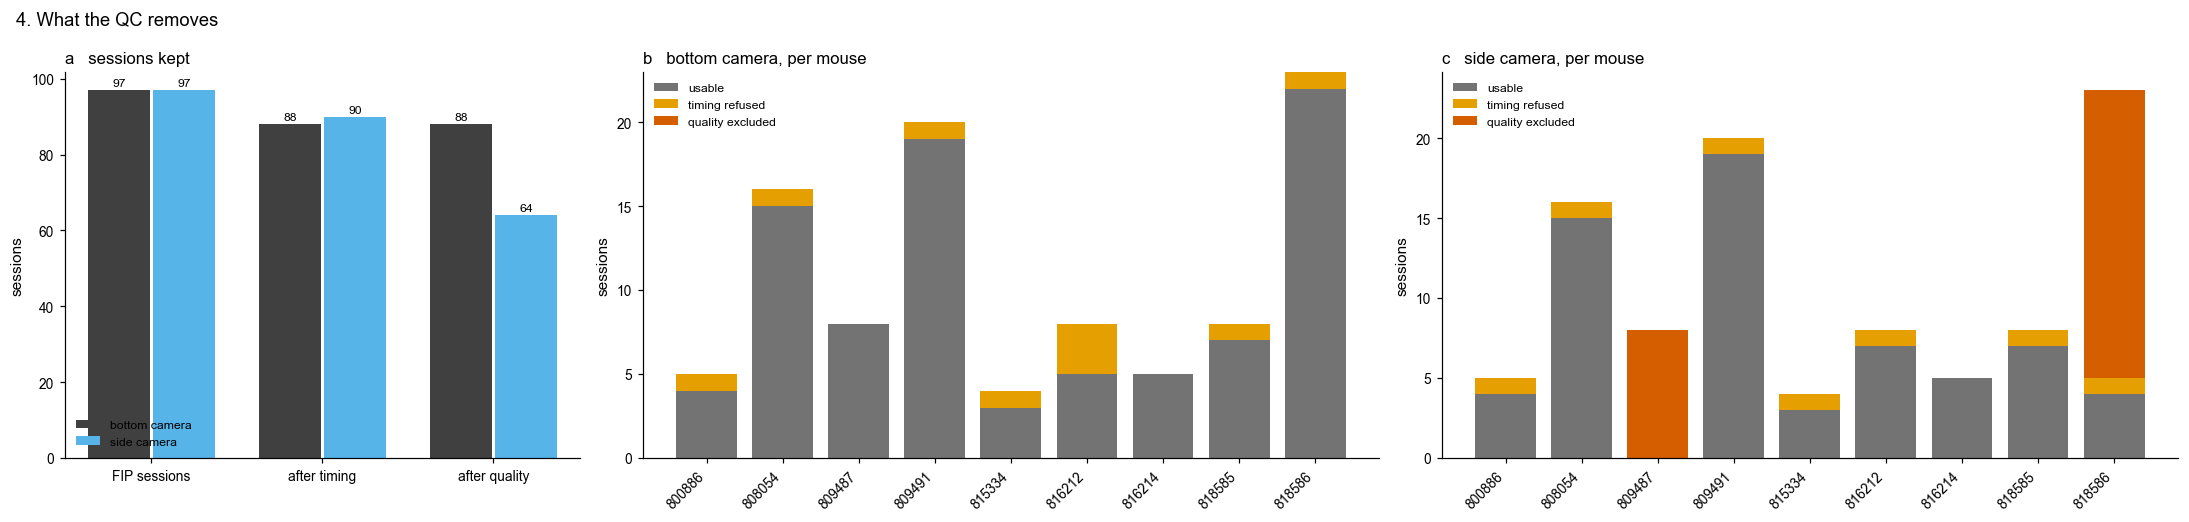

In [9]:
idx_build["outcome"] = np.select(
    [idx_build["use"], idx_build["status"] != "ok"], ["usable", "timing refused"], "quality excluded")
OUT_ORDER = ["usable", "timing refused", "quality excluded"]
OUT_COLOR = {"usable": "0.45", "timing refused": OKABE_ITO["orange"], "quality excluded": OKABE_ITO["vermillion"]}
counts = (idx_build.groupby(["camera", "subject", "outcome"]).size().unstack("outcome", fill_value=0)
          .reindex(columns=OUT_ORDER, fill_value=0))
funnel = pd.DataFrame({cam: {"sessions": idx_build.session.nunique(),
                             "after timing QC": int((idx_build[idx_build.camera == cam].status == "ok").sum()),
                             "after image-quality QC": int(idx_build[idx_build.camera == cam].use.sum())}
                       for cam in CAMERAS})
mice = pd.DataFrame({cam: {"mice": idx_build[idx_build.camera == cam].subject.nunique(),
                           "mice with usable sessions": idx_build[(idx_build.camera == cam) & idx_build.use].subject.nunique()}
                     for cam in CAMERAS})
print(pd.concat([funnel, mice]))
print()
print(counts.unstack("camera").fillna(0).astype(int))

fig, axes = plt.subplots(1, 3, figsize=(20, 4.8), gridspec_kw=dict(width_ratios=[0.7, 1, 1]))
ax = axes[0]
x = np.arange(3)
for j, cam in enumerate(CAMERAS):
    v = funnel[cam].to_numpy()
    ax.bar(x + (j - 0.5) * 0.38, v, width=0.36, color=CAM_COLOR[cam], label=f"{CAM_LABEL[cam]} camera")
    for xi, vi in zip(x + (j - 0.5) * 0.38, v):
        ax.text(xi, vi + 1, str(vi), ha="center", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(["FIP sessions", "after timing", "after quality"])
ax.set(ylabel="sessions")
ax.set_title("a   sessions kept", loc="left")
ax.legend(fontsize=8, loc="lower left")
style_ax(ax)
for j, cam in enumerate(CAMERAS):
    ax = axes[1 + j]
    c = counts.loc[cam].reindex(SUBJECTS, fill_value=0)
    bottom_ = np.zeros(len(c))
    for o in OUT_ORDER:
        ax.bar(range(len(c)), c[o], bottom=bottom_, color=OUT_COLOR[o], label=o)
        bottom_ += c[o].to_numpy()
    ax.set_xticks(range(len(c)))
    ax.set_xticklabels(SUBJECTS, rotation=45, ha="right")
    ax.set(ylabel="sessions")
    ax.set_title(f"{'bc'[j]}   {CAM_LABEL[cam]} camera, per mouse", loc="left")
    ax.legend(fontsize=8)
    style_ax(ax)
fig.suptitle("4. What the QC removes", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men01_4_numbers", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 5. Checks for the later analyses

**a** ME scale: the median raw (per-exposure) ME over the task per session. Framing, lighting and
how much of the mouse is in view differ between sessions and mice, which is why every analysis
z-scores ME per session and camera. **b** ME onsets per minute (`fu.ME_ONSET_KW`, the rule `men_00`
and the `fip_*` notebooks use), bottom camera. **c** Agreement between the cameras: zero-lag correlation of
bottom and side ME (100 Hz, z-scored) in sessions where both are usable.

         scale_BottomCamera  scale_SideCameraRight  onsets_per_min  r_bottom_side
subject                                                                          
800886                 0.18                   0.30            2.28           0.89
808054                 0.44                   0.28            2.22           0.85
809487                 0.22                    NaN            6.05            NaN
809491                 0.21                   0.28            7.28           0.93
815334                 0.11                   0.17           10.32           0.91
816212                 0.26                   0.20            2.67           0.91
816214                 0.25                   0.20            4.92           0.92
818585                 0.29                   0.39            4.10           0.89
818586                 0.26                   0.29            5.92           0.87

       onsets_per_min  r_bottom_side
count           88.00          62.00
mean             5.21  

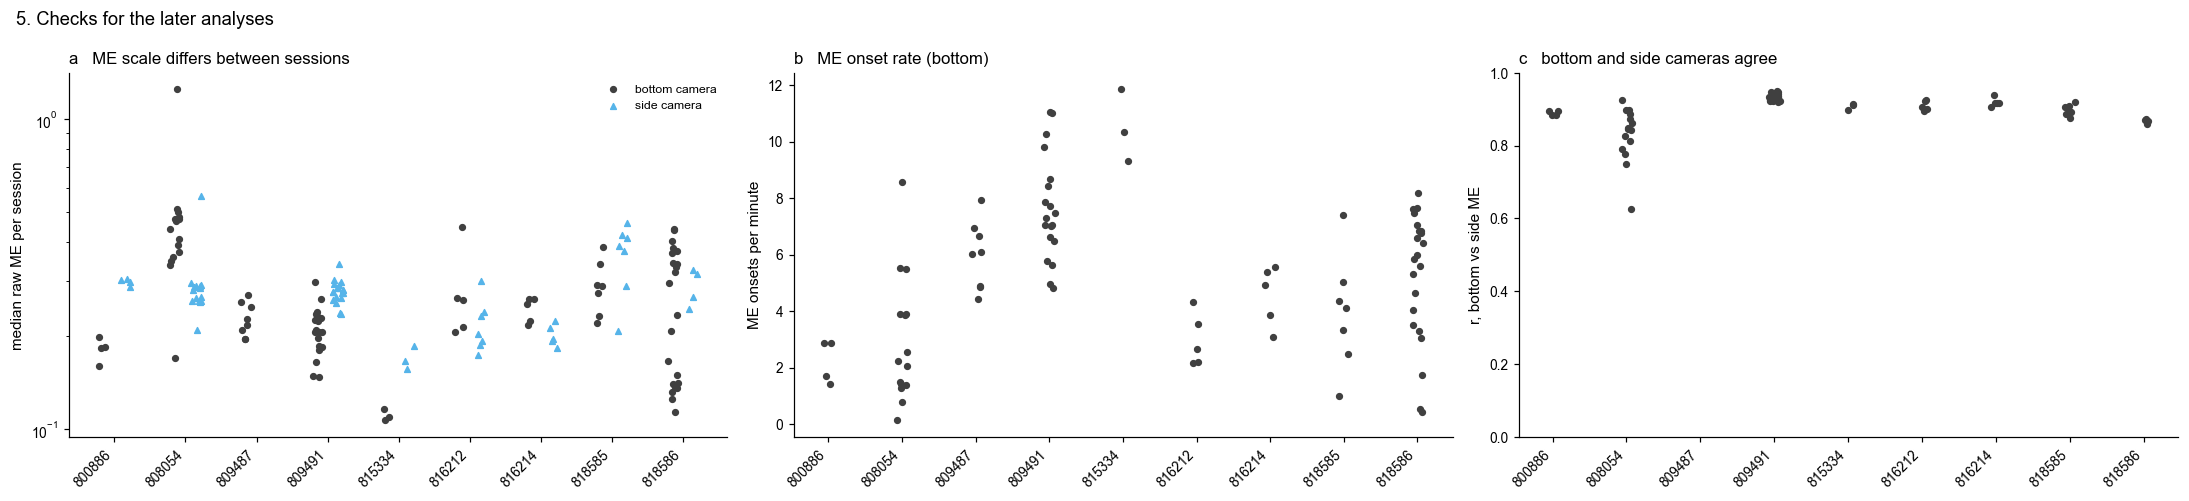

In [10]:
rows = []
for s in sessions:
    r = dict(subject=s["subject"], session=s["session"])
    for cam in CAMERAS:
        x = s["me"][cam]
        r[f"scale_{cam}"] = np.nanmedian(x) if x is not None else np.nan
    r["onsets_per_min"] = onsets_per_min(s)
    a, b = s["me_n"]["BottomCamera"], s["me_n"]["SideCameraRight"]
    if a is not None and b is not None:
        ok = np.isfinite(a) & np.isfinite(b)
        r["r_bottom_side"] = np.corrcoef(a[ok], b[ok])[0, 1]
    rows.append(r)
checks = pd.DataFrame(rows)
print(checks.groupby("subject")[[f"scale_{c}" for c in CAMERAS] + ["onsets_per_min", "r_bottom_side"]]
      .median().round(2))
print()
print(checks[["onsets_per_min", "r_bottom_side"]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 4.6))
rng = np.random.default_rng(0)


def by_mouse(ax, col, color, marker="o", offset=0.0, label=None):
    for k, subj in enumerate(SUBJECTS):
        v = checks.loc[checks.subject == subj, col].dropna()
        ax.scatter(k + offset + (rng.random(len(v)) - 0.5) * 0.15, v, s=14, color=color, marker=marker,
                   label=label if k == 0 else None)
    ax.set_xticks(range(len(SUBJECTS)))
    ax.set_xticklabels(SUBJECTS, rotation=45, ha="right")
    style_ax(ax)


ax = axes[0]
for j, cam in enumerate(CAMERAS):
    by_mouse(ax, f"scale_{cam}", CAM_COLOR[cam], "o" if j == 0 else "^", (j - 0.5) * 0.3,
             f"{CAM_LABEL[cam]} camera")
ax.set_yscale("log")
ax.set(ylabel="median raw ME per session")
ax.set_title("a   ME scale differs between sessions", loc="left")
ax.legend(fontsize=8)
ax = axes[1]
by_mouse(ax, "onsets_per_min", CAM_COLOR["BottomCamera"])
ax.set(ylabel="ME onsets per minute")
ax.set_title("b   ME onset rate (bottom)", loc="left")
ax = axes[2]
by_mouse(ax, "r_bottom_side", "0.25")
ax.set(ylabel="r, bottom vs side ME", ylim=(0, 1))
ax.set_title("c   bottom and side cameras agree", loc="left")
fig.suptitle("5. Checks for the later analyses", x=0.01, ha="left")
fig.tight_layout()
save_fig(fig, "men01_5_checks", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 6. Numbers

In [11]:
summary = pd.Series({
    "sessions": idx_build.session.nunique(),
    "cameras": len(idx_build),
    "bottom usable": int(idx_build[(idx_build.camera == "BottomCamera")].use.sum()),
    "side usable": int(idx_build[(idx_build.camera == "SideCameraRight")].use.sum()),
    "cameras refused by timing": int((idx_build.status != "ok").sum()),
    "side cameras excluded by quality": int(((idx_build.status == "ok") & ~idx_build.use).sum()),
    "usable cameras re-indexed (frames lost)": int(((idx_build.timing == "re-indexed") & idx_build.use).sum()),
    "max row-clock error avoided (s)": round(err["row_clock_error_s"].abs().max(), 1),
    "clock check |peak lag| max (ms)": round(1000 * clock["peak_lag_s"].abs().max()),
    "ME onsets/min, median": round(checks["onsets_per_min"].median(), 1),
    "bottom vs side r, median": round(checks["r_bottom_side"].median(), 2),
})
summary.to_frame("value")

,value
sessions,97.00
cameras,194.00
bottom usable,88.00
side usable,64.00
cameras refused by timing,16.00
side cameras excluded by quality,26.00
usable cameras re-indexed (frames lost),32.00
max row-clock error avoided (s),666.60
clock check |peak lag| max (ms),140.00
"ME onsets/min, median",5.30


## 7. Panels for the QC slide

The same results as single small panels with slide-sized text: the example window (bottom camera
and task events), the clock check after correction, the most overexposed side camera's reference
frame, and bottom-camera sessions per mouse.

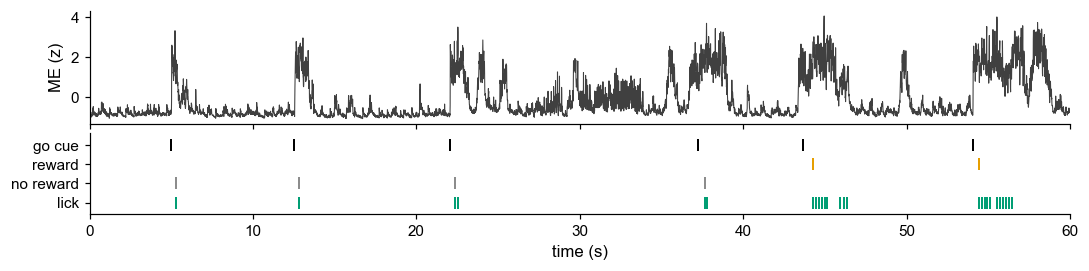

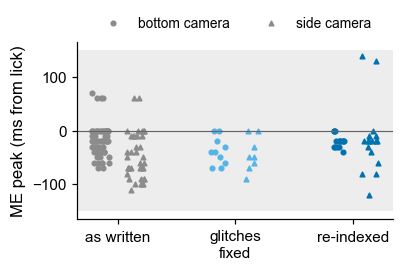

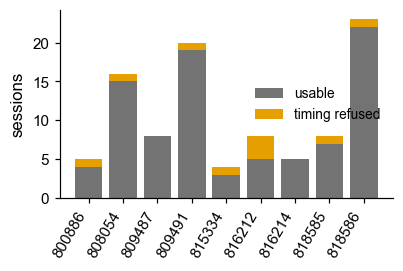

quality example: behavior_809487_2025-10-10_12-33-41 SideCameraRight, clipped 5.68%


In [12]:
SLIDE_RC = {"font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11, "xtick.labelsize": 10,
            "ytick.labelsize": 10, "legend.fontsize": 9}
with plt.rc_context(SLIDE_RC):
    # example: bottom ME over the task events, Fig 1's window, time from the window start
    fig = plt.figure(figsize=(11.5, 2.4))
    gs = GridSpec(2, 1, figure=fig, height_ratios=[1.4, 1], hspace=0.1)
    ax = fig.add_subplot(gs[0])
    ax.plot(t[m] - win[0], ex["me_n"]["BottomCamera"][m], color=CAM_COLOR["BottomCamera"], lw=0.7)
    ax.set_ylabel("ME (z)")
    ax.set_xlim(0, EXAMPLE_WIN_S)
    plt.setp(ax.get_xticklabels(), visible=False)
    style_ax(ax)
    ax2 = fig.add_subplot(gs[1], sharex=ax)
    licks = le["timestamps"]
    ev_rows = [("go cue", tr["goCue_start_time_in_session"], "k"),
               ("reward", outc[rewarded], OKABE_ITO["orange"]),
               ("no reward", outc[responded & ~rewarded], "0.55"),
               ("lick", licks, OKABE_ITO["bluish_green"])]
    for y, (name, times, color) in enumerate(ev_rows):
        tt = np.asarray(times.dropna(), float)
        tt = tt[(tt >= win[0]) & (tt < win[1])] - win[0]
        ax2.plot(tt, np.full(len(tt), -y), "|", color=color, ms=8, mew=1.3)
    ax2.set_yticks(-np.arange(len(ev_rows)))
    ax2.set_yticklabels([r[0] for r in ev_rows])
    ax2.set_ylim(-len(ev_rows) + 0.4, 0.6)
    ax2.set_xlabel("time (s)")
    style_ax(ax2)
    save_fig(fig, "men01_slide_example", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    # clock check after correction, both cameras
    fig, ax = plt.subplots(figsize=(3.8, 2.6))
    rng = np.random.default_rng(0)
    for j, cam in enumerate(CAMERAS):
        for k, cat in enumerate(TIMING_ORDER[:3]):
            v = clock.loc[(clock.camera == cam) & (clock.timing == cat), "peak_lag_s"]
            ax.scatter(k + (j - 0.5) * 0.3 + (rng.random(len(v)) - 0.5) * 0.15, v * 1000, s=9,
                       color=TIMING_COLOR[cat], marker="o" if j == 0 else "^",
                       label=f"{CAM_LABEL[cam]} camera" if k == 0 else None)
    ax.axhspan(-CLOCK_TOL_S * 1000, CLOCK_TOL_S * 1000, color="0.93", lw=0, zorder=0)
    ax.axhline(0, color=PALETTE["neutral"], lw=0.8)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["as written", "glitches\nfixed", "re-indexed"])
    ax.set_ylabel("ME peak (ms from lick)")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False)
    style_ax(ax)
    fig.tight_layout()
    save_fig(fig, "men01_slide_clock", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

    # bottom-camera sessions per mouse
    fig, ax = plt.subplots(figsize=(3.8, 2.6))
    c = counts.loc["BottomCamera"].reindex(SUBJECTS, fill_value=0)
    base = np.zeros(len(c))
    for o in ("usable", "timing refused"):
        ax.bar(range(len(c)), c[o], bottom=base, color=OUT_COLOR[o], label=o)
        base += c[o].to_numpy()
    ax.set_xticks(range(len(c)))
    ax.set_xticklabels(SUBJECTS, rotation=60, ha="right")
    ax.set_ylabel("sessions")
    ax.legend(frameon=False)
    style_ax(ax)
    fig.tight_layout()
    save_fig(fig, "men01_slide_numbers", fig_dir=FIG_DIR, save=SAVE_FIG)
    plt.show()

# the most overexposed side camera's reference frame, as an image file
lab, r, im = crops[2]
if im is not None and SAVE_FIG:
    os.makedirs(FIG_DIR, exist_ok=True)
    im.convert("RGB").save(os.path.join(FIG_DIR, "men01_slide_quality.png"))
print(f"quality example: {r['session']} {r['camera']}, clipped {r['pct_clipped_high']:.2f}%")